In [ ]:
!pip install xgboost==3.2.0

In [ ]:
!pip install shap

In [ ]:
!pip install m2cgen

In [1]:
import numpy as np
import pandas as pd
import random

np.random.seed(42)
ph = np.random.normal(7,0.5,500)
turbidity = np.random.lognormal(2,0.8,500)
chlorine = np.random.lognormal(-0.5,0.6,500)
UV = np.random.lognormal(-1.2,0.4,500)
ORP = np.random.normal(300,60,500)

df = pd.DataFrame({
    'ph': ph,
    'turbidity': turbidity,
    'Cl residual': chlorine,
    'UV': UV,
    'ORP': ORP})

print(df.head())

         ph  turbidity  Cl residual        UV         ORP
0  7.248357  15.501581     1.404404  0.411208  259.489304
1  6.930868  34.039898     1.056308  0.241599  291.328880
2  7.323844   2.413664     0.628624  0.217126  252.454805
3  7.761515  11.592698     0.411411  0.300788  281.522308
4  6.882923   4.390688     0.922133  0.281373  186.383120


In [2]:
df['label'] = None
df['confidence'] = None

df.loc[(df['ph'] < 6.25) | (df['ph'] > 7.75), 'label'] = 'risk'
df.loc[(df['ph'] < 6.25) | (df['ph'] > 7.75), 'confidence'] = 0.3
df.loc[(df['ph'] < 6) | (df['ph'] > 8), 'confidence'] = 0.6
df.loc[(df['ph'] < 5.5) | (df['ph'] > 8.5), 'confidence'] = 0.9

df.loc[df['turbidity'] > 25, 'label'] = 'risk'
df.loc[df['turbidity'] > 25,'confidence'] = 0.3
df.loc[df['turbidity'] > 35,'confidence'] = 0.6
df.loc[df['turbidity'] > 45,'confidence'] = 0.9

df.loc[df['Cl residual'] < 0.25, 'label'] = 'risk'
df.loc[df['Cl residual'] < 0.25,'confidence'] = 0.3
df.loc[df['Cl residual'] < 0.2,'confidence'] = 0.6
df.loc[df['Cl residual'] < 0.1,'confidence'] = 0.9

df.loc[df['UV'] > 0.5, 'label'] = 'risk'
df.loc[df['UV'] > 0.5,'confidence'] = 0.3
df.loc[df['UV'] > 0.65,'confidence'] = 0.6
df.loc[df['UV'] > 0.8,'confidence'] = 0.9

df.loc[df['ORP'] < 200, 'label'] = 'risk'
df.loc[df['ORP'] < 200,'confidence'] = 0.3
df.loc[df['ORP'] < 150,'confidence'] = 0.6
df.loc[df['ORP'] < 100,'confidence'] = 0.9

df.loc[df['label'].isna(), 'label'] = 'safe'
df.loc[df['confidence'].isna(), 'confidence'] = 0.1

no_report = df.sample(frac=0.1).index
df.loc[no_report, 'label'] = None
df.loc[no_report, 'confidence'] = None

print(df.head(20))

          ph  turbidity  Cl residual        UV         ORP label confidence
0   7.248357  15.501581     1.404404  0.411208  259.489304  safe        0.1
1   6.930868  34.039898     1.056308  0.241599  291.328880  risk        0.3
2   7.323844   2.413664     0.628624  0.217126  252.454805  safe        0.1
3   7.761515  11.592698     0.411411  0.300788  281.522308  risk        0.3
4   6.882923   4.390688     0.922133  0.281373  186.383120  risk        0.3
5   6.882932   5.004311     0.768044  0.251254  312.797622  safe        0.1
6   7.789606   4.600131     1.037813  0.397944  300.072329  risk        0.3
7   7.383717   3.701756     0.887899  0.441367  250.974682  safe        0.1
8   6.765263   7.681519     1.138523  0.312036  339.554740  None       None
9   7.271280   3.800908     0.439929  0.543901  356.254208  None       None
10  6.768291   9.173927     1.337011  0.190772  203.546408  safe        0.1
11  6.767135   7.097975     0.682877  0.278743  254.236513  safe        0.1
12  7.120981

In [3]:
df['confidence'].value_counts()

#(df['UV']>0.5).sum()
#(df['ph']<6.25).sum()
#(df['Cl residual'] < 0.25).sum()

confidence
0.1    301
0.3    109
0.6     30
0.9     10
Name: count, dtype: int64

In [4]:
import xgboost as xgb
from xgboost import XGBClassifier

In [5]:
import sys
print(sys.executable)

C:\Users\44748\anaconda3\python.exe


In [6]:
labelled = df[(df['label'] == 'risk') | (df['label'] == 'safe') ]
features = labelled[['ph','turbidity','Cl residual','UV','ORP']]
labels = (labelled['label'] == 'risk').astype(int)
weights = labelled['confidence']

labels.head(10)

0     0
1     1
2     0
3     1
4     1
5     0
6     1
7     0
10    0
11    0
Name: label, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

print(features.head())
print(X_train.head())

         ph  turbidity  Cl residual        UV         ORP
0  7.248357  15.501581     1.404404  0.411208  259.489304
1  6.930868  34.039898     1.056308  0.241599  291.328880
2  7.323844   2.413664     0.628624  0.217126  252.454805
3  7.761515  11.592698     0.411411  0.300788  281.522308
4  6.882923   4.390688     0.922133  0.281373  186.383120
           ph  turbidity  Cl residual        UV         ORP
27   7.187849   7.678836     0.651824  0.558387  374.336781
19   6.293848  13.478687     0.782313  0.632318  225.644496
73   7.782322   6.201056     0.280889  0.175059  311.838942
162  7.579298   7.197958     0.263489  0.128897  329.893305
276  7.099530   4.130053     2.439023  0.235815  340.762397


In [9]:
W_train = weights.loc[X_train.index]

model = XGBClassifier(random_state=42, base_score = 0.5)
model.fit(X_train, Y_train, sample_weight = W_train)

XGBClassifier(base_score=0.5, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [10]:
from sklearn.metrics import classification_report
Y_pred = model.predict(X_test) #Binary Classification via a threshold of 0.5
Y_prob = model.predict_proba(X_test)[:,1]
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        68
           1       0.88      1.00      0.94        22

    accuracy                           0.97        90
   macro avg       0.94      0.98      0.96        90
weighted avg       0.97      0.97      0.97        90



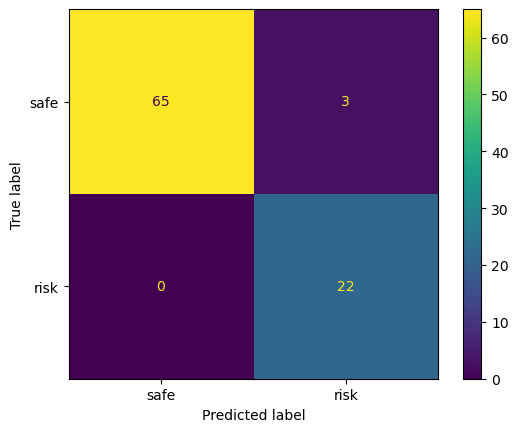

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(Y_test, Y_pred)
display = ConfusionMatrixDisplay(cm, display_labels=['safe','risk'])
display.plot()

ROC Curve - Plots False Positives (Fraction of the safe readigns that were marked as safe) against True Positives (Fraction of the risky readings that were marked as risky) as you vary the assignment probability threshold. An AUC (Area under the curve) score is used where 1 = perfect model and 0.5 = guess as singular metric for model quality.

AUC Score: 1.0


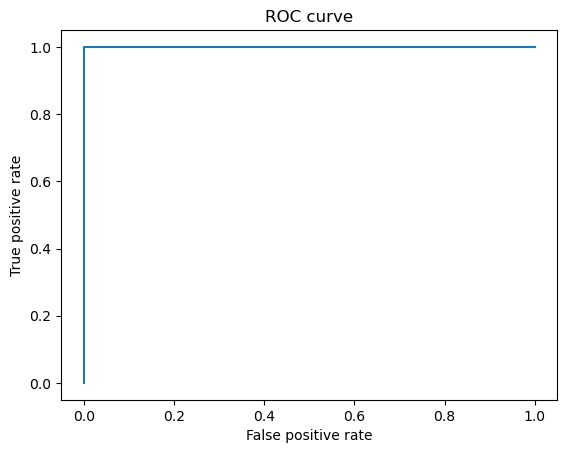

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob) #false positive rate, true positive rate

plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")


print("AUC Score:", roc_auc_score(Y_test, Y_prob))

Finally we will produce a SHAP summary plot, which indicates how much each metric influenced the prediction of risk (positive indicates pushed towards).

In [13]:
import shap

C:\Users\44748\AppData\Local\Temp\ipykernel_35724\948638661.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


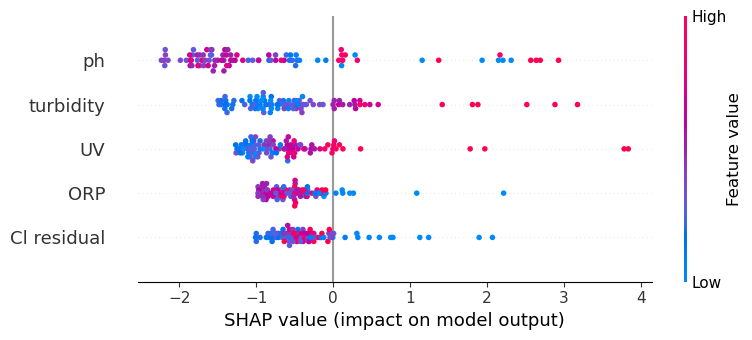

In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [15]:
import json

model.save_model('model.json')

with open('model.json','r') as file:
    content = json.load(file)

lines = json.dumps(content, indent=2)

#print(lines[0:850]) - beginning of tree details shown
#print(lines[78680:80950]) - tree number 28 shown

In [29]:
import m2cgen as thisbetterwork

code = thisbetterwork.export_to_c(model)

print(code[250:1000])

if (input[3] < 0.49010453) {
        if (input[0] < 7.528561) {
            if (input[1] < 23.513678) {
                if (input[0] < 6.275958) {
                    var0 = 0.32500002;
                } else {
                    if (input[4] < 208.13354) {
                        var0 = 0.21951221;
                    } else {
                        if (input[2] < 0.33858895) {
                            var0 = 0.051851857;
                        } else {
                            var0 = -0.49743593;
                        }
                    }
                }
            } else {
                var0 = 0.40444446;
            }
        } else {
            var0 = 0.40219784;
        }
    } else {
        var0 = 0.4777778;
    


In [30]:
with open('water_quality_edge.c','w') as file:
    file.write(code)